###Import Statements

In [ ]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import ast
import json
import csv


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/large_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

In [ ]:
# Ensure numvars is int
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    # Fallback if column missing: infer from variables length
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

3_17_13 3 6
4_49_17 4 12
alu-v0_26 5 6
graycode6_47 6 5
hwb4_51 4 11
mod5d1_63 5 7
rd32-v0_66 4 4
4gt12-v0_86 5 14
one-two-three-v0_97 5 11
ham3_102 3 5
cycle10_2_110 12 19
sys6-v0_144 10 12
cnt3-5_180 16 20


###Functions for fault model simulation and fault detection

In [ ]:
# ---------- Fault Model ---------- #
def simulate_circuit(circuit, vec):
    """Simulate circuit on a boolean vector.

    Internal gate formats:
      ("TOFFOLI", controls_list, target_idx)
      ("FREDKIN", (controls_list, s1_idx, s2_idx))
    """
    v = vec.copy()
    for gate in circuit:
        gtype = gate[0]
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(v[c] == 1 for c in controls):
                v[target] ^= 1
        elif gtype == "FREDKIN":
            controls_list, s1, s2 = gate[1]
            if all(v[c] == 1 for c in controls_list):
                v[s1], v[s2] = v[s2], v[s1]
        else:
            # Unknown gate type: ignore (or raise if you prefer)
            pass
    return v

In [ ]:
def generate_caf_faults(circuit, n_inputs):
    """Generate Control Appearance Faults (CAF) for each gate."""
    fault_list = []
    for i, gate in enumerate(circuit):
        gtype = gate[0]
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            # Try adding each possible new control
            for new_ctrl in range(n_inputs):
                if new_ctrl not in controls and new_ctrl != target:
                    faulty_controls = controls + [new_ctrl]
                    faulty_gate = ("TOFFOLI", faulty_controls, target)
                    faulty_circuit = circuit[:i] + [faulty_gate] + circuit[i+1:]
                    fault_list.append({
                        "id": f"CAF_{i}_{new_ctrl}",
                        "type": "CAF",
                        "location": i,
                        "circuit": faulty_circuit
                    })
        elif gtype == "FREDKIN":
            controls_list, s1, s2 = gate[1]
            for new_ctrl in range(n_inputs):
                if new_ctrl not in controls_list and new_ctrl not in (s1, s2):
                    faulty_controls = controls_list + [new_ctrl]
                    faulty_gate = ("FREDKIN", (faulty_controls, s1, s2))
                    faulty_circuit = circuit[:i] + [faulty_gate] + circuit[i+1:]
                    fault_list.append({
                        "id": f"CAF_{i}_{new_ctrl}",
                        "type": "CAF",
                        "location": i,
                        "circuit": faulty_circuit
                    })
    return fault_list

In [ ]:
def generate_fault_list_with_types(circuit, n_inputs):
    fault_list = []

    # Control Appearance Faults
    fault_list.extend(generate_caf_faults(circuit, n_inputs))

    return fault_list


In [ ]:
def detect_fault(dp, vector, fault, circuit):
    key = (tuple(vector), fault["id"])
    if key in dp:
        return dp[key]
    normal_output = simulate_circuit(circuit, vector)
    faulty_output = simulate_circuit(fault["circuit"], vector)
    detected = normal_output != faulty_output
    dp[key] = detected
    return detected

###Fitness Calulation

In [ ]:
# ---------- Fitness (Coverage-first) ---------- #
def compute_fitness(individual, fault_list, circuit, dp, alpha=100, beta=0.01):
    detected_faults = set()
    for vector in individual:
        for fault in fault_list:
            if detect_fault(dp, vector, fault, circuit):
                detected_faults.add(fault["id"])

    coverage = len(detected_faults) / len(fault_list) if fault_list else 0.0
    if coverage < 1.0:
        fitness = alpha * coverage
    else:
        fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults

###Mutation and Crossover

In [ ]:
# ---------- GA Operators ---------- #
def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def mutate(individual, mutation_rate=0.2):
    for vec in individual:
        if random.random() < mutation_rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

In [ ]:
def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            if fault["id"] not in covered and detect_fault(dp, vec, fault, circuit):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced

###GA+DP Approach

In [ ]:
# ---------- GA Core ---------- #
def run_ga(circuit, n_inputs, generations=50, pop_size=25, max_vecs= 20, runs=5):

    fault_list = generate_fault_list_with_types(circuit, n_inputs)
    best_results = []

    for _ in range(runs):

        dp = {}
        population = [
            [[random.randint(0, 1) for _ in range(n_inputs)]
             for _ in range(random.randint(2, max_vecs))]
            for _ in range(pop_size)
        ]
        for _ in range(generations):
          fitness_scores = [compute_fitness(ind, fault_list, circuit, dp) for ind in population]
          population = [x for _, x in sorted(zip(fitness_scores, population), reverse=True)]

          # Elitism: always keep the top one
          next_gen = [population[0]]

          while len(next_gen) < pop_size:
              p1, p2 = random.sample(population[:pop_size // 2], 2)
              child = crossover(p1, p2)
              child = mutate(child)
              next_gen.append(child)

          population = next_gen


        best = max(population, key=lambda ind: compute_fitness(ind, fault_list, circuit, dp)[0])
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp)
        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))

    return best_results


###Run over the benchmark circuits

In [ ]:
def convert_dataset_gates(dataset_gates, variables):
    """Convert dataset gates (e.g., {'gate':'t3','vars':[...]} or 'f4', etc.)
       into internal tuples for simulator."""
    # Ensure variables is a list (not a string)
    if isinstance(variables, str):
        variables = ast.literal_eval(variables)

    var_map = {v: i for i, v in enumerate(variables)}
    circuit = []

    for g in dataset_gates:
        # Defensive: skip malformed entries
        if not isinstance(g, dict) or "gate" not in g or "vars" not in g:
            continue

        gate_name = str(g["gate"]).lower()   # e.g., 't3', 'f4'
        names = g["vars"]                    # variable names
        # Map names -> indices (skip names not found)
        idxs = [var_map[n] for n in names if n in var_map]
        if len(idxs) == 0:
            continue

        if gate_name.startswith('t'):
            # Toffoli: last is target, others are controls
            if len(idxs) == 1:
                controls, target = [], idxs[0]
            else:
                controls, target = idxs[:-1], idxs[-1]
            circuit.append(("TOFFOLI", controls, target))

        elif gate_name.startswith('f'):
            # Fredkin: last two are swap targets, preceding are controls (can be 0,1, or many)
            if len(idxs) < 2:
                continue
            controls = idxs[:-2]
            s1, s2 = idxs[-2], idxs[-1]
            circuit.append(("FREDKIN", (controls, s1, s2)))

        else:
            # Unknown gate family → ignore (or map to NOT if 1-ary, etc.)
            # If you want NOT: if len(idxs)==1: circuit.append(("TOFFOLI", [], idxs[0]))
            pass

    return circuit

In [ ]:
# ---------- Run over dataset ---------- #
def run_on_dataset(df, save_csv_path="ga_results.csv"):
    results = []
    for _, row in df.iterrows():
        variables = row["variables"]
        circuit = convert_dataset_gates(row["gates"], variables)
        n_inputs = int(row["numvars"])

        if not circuit:
            print(f"⚠️ {row['circuit_name']} → Circuit empty or unsupported gates, skipping.")
            results.append({
                "file": row['circuit_name'],
                "fitness": None,
                "coverage": None,
                "total_faults": None,
                "detected_faults": None,
                "detected_ids": None,
                "test_vectors": None,
                "num_test_vectors": None,
                "num_gates": 0,
                "exec_time_sec": 0
            })
            continue

        start_time = time.time()
        best_runs = run_ga(circuit, n_inputs)
        end_time = time.time()
        execution_time = round(end_time - start_time, 2)

        best_test_set, (fitness, coverage, total_faults, detected_faults) = max(
            best_runs, key=lambda x: x[1][0]
        )
        results.append({
            "file": row['circuit_name'],
            "fitness": round(fitness, 4),
            "coverage": round(coverage, 4),
            "total_faults": total_faults,
            "detected_faults": len(detected_faults),
            "detected_ids": list(sorted(detected_faults)),
            "test_vectors": best_test_set,
            "num_test_vectors": len(best_test_set),
            "num_gates": len(circuit),
            "exec_time_sec": execution_time
        })

    # Save CSV of GA outcomes
    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["file", "fitness", "coverage", "total_faults", "detected_faults",
                        "num_test_vectors", "num_gates", "exec_time_sec"]
        )
        writer.writeheader()
        for row in results:
            if isinstance(row["fitness"], (int, float)):
                writer.writerow({key: row[key] for key in writer.fieldnames})
    return results


###Visualiza the Results

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

### --- Plotting Functions --- ###

def plot_gates_coverage_vectors(results):
    filtered = [r for r in results if isinstance(r["fitness"], (int, float))]
    if not filtered:
        print("No successful results to plot.")
        return
    files = [r["file"] for r in filtered]
    num_gates = [r["num_gates"] for r in filtered]
    coverage = [r["coverage"] for r in filtered]
    num_vectors = [r["num_test_vectors"] for r in filtered]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))

    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()

    lines, labels = [], []
    for ax in [ax1, ax2, ax3]:
        for line in ax.get_lines():
            lines.append(line)
            labels.append(line.get_label())
    fig.legend(lines + [bars], labels + ["Gate Count"], loc="upper right", bbox_to_anchor=(1.15, 1))
    plt.show()

def plot_coverage_vs_vectors(results):
    filtered = [r for r in results if isinstance(r["fitness"], (int, float))]
    if not filtered:
        print("No successful results to plot.")
        return
    x = [r["num_test_vectors"] for r in filtered]
    y = [r["coverage"] for r in filtered]
    labels = [r["file"] for r in filtered]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_efficiency(results):
    filtered = [r for r in results if isinstance(r["fitness"], (int, float))]
    if not filtered:
        print("No successful results to plot.")
        return
    efficiency = [
        (r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0
        for r in filtered
    ]
    labels = [r["file"] for r in filtered]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()


In [ ]:
# Run GA + DP on the dataset
results = run_on_dataset(df_circuits, save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/results/large_caf.csv")

In [ ]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [ ]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



3_17_13 → gates: 6, vectors: 3, time: 0.26 sec
4_49_17 → gates: 12, vectors: 5, time: 3.38 sec
alu-v0_26 → gates: 6, vectors: 4, time: 2.76 sec
graycode6_47 → gates: 5, vectors: 6, time: 2.43 sec
hwb4_51 → gates: 11, vectors: 5, time: 1.45 sec
mod5d1_63 → gates: 7, vectors: 7, time: 2.0 sec
rd32-v0_66 → gates: 4, vectors: 3, time: 0.4 sec
4gt12-v0_86 → gates: 14, vectors: 7, time: 2.65 sec
one-two-three-v0_97 → gates: 11, vectors: 6, time: 2.14 sec
ham3_102 → gates: 5, vectors: 3, time: 0.13 sec
cycle10_2_110 → gates: 19, vectors: 15, time: 209.5 sec
sys6-v0_144 → gates: 10, vectors: 13, time: 18.95 sec
cnt3-5_180 → gates: 20, vectors: 26, time: 334.16 sec


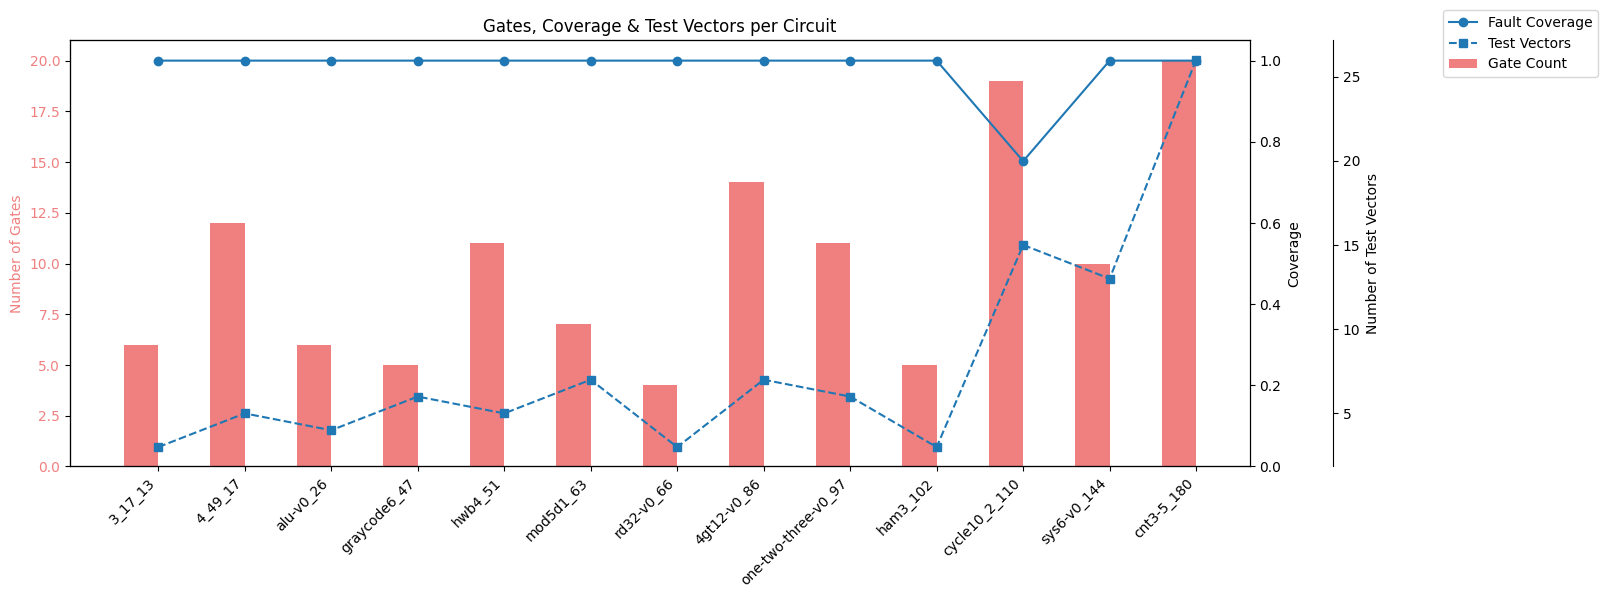

In [ ]:
plot_gates_coverage_vectors(results)


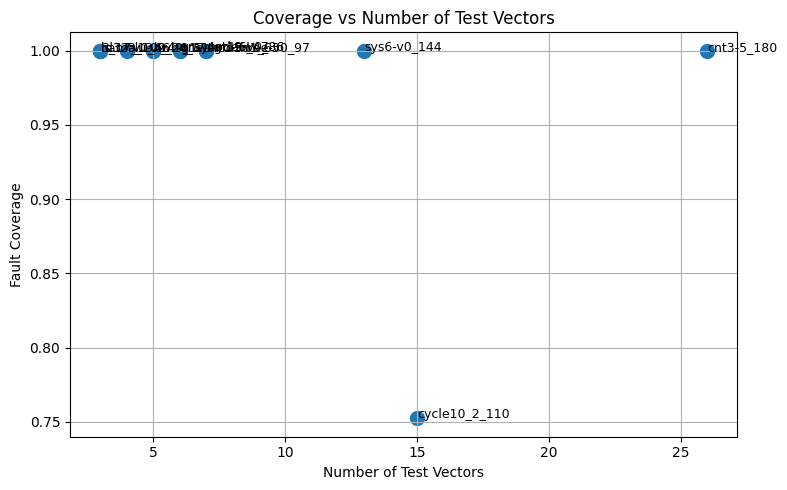

In [ ]:
plot_coverage_vs_vectors(results)

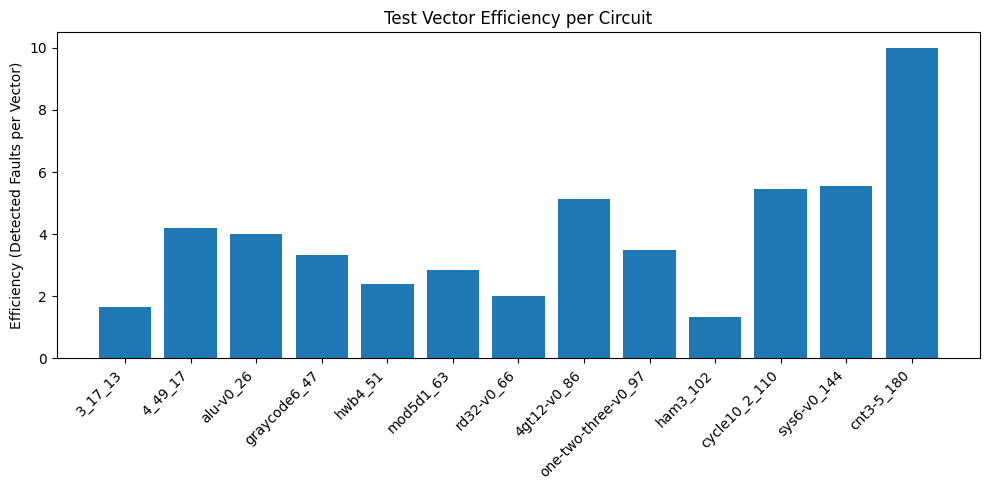

In [ ]:
plot_efficiency(results)
# ---------- Example Execution ---------- #


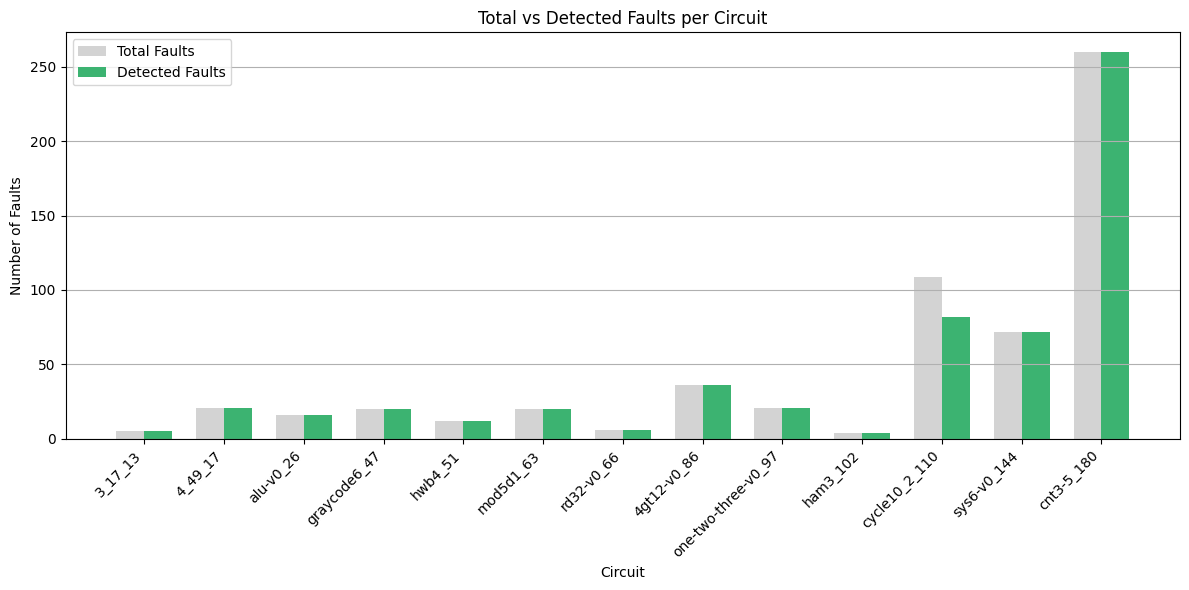

In [ ]:
plot_faults_per_circuit(results)
